# Variable-mean noise: LN models across a luminance step

**The experiment.** `VariableMeanNoise` delivers Gaussian noise of constant contrast **through
an LED** while the mean light level steps periodically. One epoch therefore contains steps in
both directions, and the question is how the cell's linear-nonlinear model changes as it adapts
to each new mean.

The protocol lives in two packages —
`edu.washington.riekelab.rieke.protocols.VariableMeanNoise` and
`edu.washington.riekelab.turner.protocols.VariableMeanNoise` — and they are the same protocol:
the recorded epoch parameters are identical, verified against the stored epochs rather than
assumed. Both are searched together and `protocol_name` says which one a block came from.


Model fitting is **cascadegraph**, vendored at `retinanalysis.utils.cascadegraph` — the Python
port of the library the MATLAB used. Nothing here reimplements a filter or a sigmoid.

In [1]:
import contextlib
import importlib
import io
import json
import html
import ipywidgets as widgets
import sys
import time
from pathlib import Path

if sys.version_info[:2] != (3, 11):
    raise RuntimeError(
        f'This notebook requires the retinanalysis Python 3.11 kernel; '
        f'got Python {sys.version.split()[0]} at {sys.executable}')
import_started = time.perf_counter()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import retinanalysis as ra
from retinanalysis.SCutils import explore as sc

# The analysis module sits beside this notebook: it is specific to this project.
sys.path.insert(0, str(Path.cwd()))
import variable_mean_noise as vmn

print(f'Python {sys.version.split()[0]} | {sys.executable}')
print(f'Imports ready in {time.perf_counter() - import_started:.2f} s')

Python 3.11.13 | /Users/chrischen/opt/anaconda3/envs/retinanalysis/bin/python
Imports ready in 1.07 s


## 1. Discover target primate VariableMeanNoise cells

Use the experiment's `label == 'Primate'` rather than guessing species from cell type, while explicitly retaining the requested ON/OFF midget, ON/OFF parasol, and AII/A2 aliases when an older experiment label disagrees. This also keeps less common types recorded in Primate experiments. **No rig filter is applied:** the experiment-name rig suffix is provenance only, and Section 1 prints every retained suffix and its block count. A cell is retained only when at least one exact duration × contrast condition contains two mean-light levels and every retained epoch is at least 30 s. Multiple contrasts are separated, not used to discard the whole cell. Legacy array-valued `lightMean` entries are resolved per epoch from `stdv / Contrast` and checked against the recorded candidates. The checked-in index registry preserves every pre-fix Section 1 index and appends recovered cells after 124. The MATLAB roster below audits known-good entries but never restricts broader discovery.

### 1a. Recording type per block

Resolve one recording type per epoch block with the trained SCutils classifier and parser. Training uses only
epoch groups whose `recordingTechnique` is explicitly `cell-attached` or `whole-cell`; six raw epochs are
pooled into one feature vector per block, never treated as independent training examples. Validation holds out
entire cells. For labelled training blocks, retroactive audits use the cell-held-out prediction rather than an
in-sample fit. Epoch-group metadata remains the normal anchor, but a ≥90% confidence classifier disagreement
can correct a stale label. Positive series resistance always forces whole-cell. Blocks are then sorted by
acquisition time within each cell and constrained to the experimental sequence: cell-attached first, followed
by at most one irreversible transition to whole-cell. `onlineAnalysis`, when present, supplies `exc` versus
`inh`; otherwise mean current is used only after whole-cell has been established. Remaining uncertainty stays
visible for an explicit Section 2 override after the raw traces have been inspected.

The result is cached in `block_modes.csv` beside the notebook for a stable, auditable Section 1 table.
Set `REFRESH_MODE_CACHE = True` to rebuild it; newly discovered blocks also trigger a refresh.

In [8]:
REFRESH_MODE_CACHE = False  # set True only when retraining/refreshing the cache

protocol_blocks = vmn.find_blocks(show=True, height=0)

block_modes = vmn.load_block_modes()
cached_block_ids = set(block_modes.block_id.dropna().astype(int))
discovered_block_ids = set(protocol_blocks.block_id.astype(int))
missing_mode_blocks = sorted(discovered_block_ids - cached_block_ids)
if missing_mode_blocks:
    print(f'\nmode cache is missing {len(missing_mode_blocks)} newly discovered block(s)')
if REFRESH_MODE_CACHE or block_modes.empty or missing_mode_blocks:
    print(f'\nbuilding {vmn.MODE_CACHE_PATH.name} with the trained block classifier/parser ...')
    block_modes = vmn.build_mode_cache(protocol_blocks)

print(f'\nrecording types over {len(block_modes)} cached blocks:')
print(block_modes.rec_type.value_counts(dropna=False).to_string())

protocol_cells = vmn.find_protocol_cells(protocol_blocks, modes=block_modes,
                                        show=True, height=460)

# The MATLAB roster is a recovery audit, not a whitelist: all valid primate
# cells remain selectable, and every known-good MATLAB entry is checked.
matlab_roster = vmn.load_summary(show=False)
matlab_discovery_audit = vmn.audit_matlab_roster_discovery(
    matlab_roster, protocol_cells, modes=block_modes, show=True)
sc.scroll_table(
    matlab_discovery_audit[['matlab_index', 'status', 'recorded_date',
                            'corrected_date', 'matlab_cell_label',
                            'matlab_rec_type', 'matlab_epoch_seconds',
                            'cell_index', 'discovered_exp_name',
                            'discovered_cell_type', 'cell_type_agrees',
                            'available_conditions', 'reason']],
    height=360, num_cols=('matlab_index', 'matlab_epoch_seconds', 'cell_index'))


405 blocks | 50 experiments | 198 cells
  rig suffixes retained (provenance only; no rig filter): B (131), E (15), G (259)
  dropped 1227 block(s) with stimTime < 30 s
  dropped 108 block(s) outside Primate experiments and the explicitly retained cell-type aliases
experiment_label  cell_type_short
Mouse             OFF-transient      46
                  ON-alpha           40
                  OFF-sustained      19
                  RGC                 2
                  ON-transient        1
  by protocol: edu.washington.riekelab.rieke.protocols.VariableMeanNoise 294, edu.washington.riekelab.turner.protocols.VariableMeanNoise 111


exp_name,rig_suffix,experiment_label,cell_label,cell_type_short,block_id,preTime,stim_seconds,tailTime,led,ndfs,frequencyCutoff,numberOfFilters,Contrast,n_epochs,protocol_name
2020-06-11_B,B,Primate,Cell10,ON-parasol,30238,,30,,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,14,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,B,Primate,Cell11,ON-midget,30209,,60,,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,2,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,B,Primate,Cell11,ON-midget,30210,,60,,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,20,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,B,Primate,Cell12,OFF-parasol,30188,,30,,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,15,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,B,Primate,Cell13,ON-parasol,30174,,30,,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,19,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,B,Primate,Cell13,ON-parasol,30177,,30,,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,6,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,B,Primate,Cell14,ON-parasol,30216,,30,,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,14,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,B,Primate,Cell14,ON-parasol,30218,,30,,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,27,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-16_B,B,Primate,Cell3,ON-parasol,30318,,60,,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,10,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-16_B,B,Primate,Cell3,ON-parasol,30319,,30,,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,11,edu.washington.riekelab.rieke.protocols.VariableMeanNoise



recording types over 405 cached blocks:
rec_type
extracellular    249
exc              149
inh                5
NaN                2
189 cells across 48 experiments
  dropped 9 cell(s) with no >=30 s duration x contrast condition containing at least 2 means
    exp_name cell_label  cell_type light_means light_contrast stim_seconds
2021-08-18_B      Cell3  ON-midget         0.5            0.3           30
2025-01-21_G      Cell1 ON-parasol         0.3            0.5       30, 60
2025-01-21_G      Cell2 ON-parasol         0.3            0.5           30
2025-01-21_G      Cell3 ON-parasol         0.3            0.5           30
2025-01-28_G      Cell1 ON-parasol         0.3            0.9           60
2025-01-28_G      Cell2 ON-parasol         0.3       0.8, 0.9       30, 60
2025-02-12_G      Cell2 ON-parasol        0.03            0.9           60
2025-02-12_G      Cell3 ON-parasol         0.3            0.9           60
2025-02-19_G      Cell2 ON-parasol       0.003            0.9     

exp_name,cell_index,cell_label,cell_type,n_extracellular,n_exc,n_inh,n_unresolved,light_means,light_contrast,n_eligible_conditions,stim_seconds,led
2020-06-11_B,0,Cell10,ON-parasol,0,14,0,0,"0.3, 3",0.5,1,30,UV LED
,1,Cell11,ON-midget,0,22,0,0,"0.3, 3",0.5,1,60,UV LED
,2,Cell12,OFF-parasol,15,0,0,0,"0.3, 3",0.5,1,30,UV LED
,3,Cell13,ON-parasol,19,6,0,0,"0.3, 3",0.5,1,30,UV LED
,4,Cell14,ON-parasol,14,27,0,0,"0.3, 3",0.5,1,30,UV LED
2020-06-16_B,5,Cell3,ON-parasol,21,53,0,0,"0.08, 0.3, 0.8, 3",0.5,2,"30, 60",UV LED
2020-06-23_B,6,Cell10,OFF-parasol,10,0,0,0,"0.3, 3",0.5,1,30,UV LED
,7,Cell8,ON-midget,20,0,0,0,"0.1, 1",0.5,1,30,UV LED
2021-02-01_B,8,cell1,ON-parasol,62,0,0,0,"0.05, 0.08, 0.5, 1, 5",0.5,1,30,UV LED
,9,cell2,ON-midget,31,0,0,0,"0.05, 0.5, 5",0.5,1,30,UV LED


status
available                                 49
condition mismatch                         3
available using recorded-date fallback     1

MATLAB roster entries not recovered exactly:
 matlab_index recorded_date corrected_date matlab_cell_label matlab_rec_type  matlab_epoch_seconds             status                                                                                                                       reason
           10    2021-04-25     2021-04-27             cell4   extracellular                  50.0 condition mismatch date and case-sensitive label found, but recording type and/or epoch duration did not identify a retained two-mean condition
           32    2020-08-09     2020-08-11             cell7             exc                   NaN condition mismatch date and case-sensitive label found, but recording type and/or epoch duration did not identify a retained two-mean condition
           34    2021-10-05     2021-10-07             Cell3             exc       

matlab_index,status,recorded_date,corrected_date,matlab_cell_label,matlab_rec_type,matlab_epoch_seconds,cell_index,discovered_exp_name,discovered_cell_type,cell_type_agrees,available_conditions,reason
0,available,2020-07-27,2020-07-29,cell5,extracellular,60.0,136,2020-07-29_G,ON-parasol,True,"2020-07-29_G: extracellular, 60s, contrast 0.4, 0.01, 0.3",
1,available,2020-08-23,2020-08-25,cell3,extracellular,55.0,156,2020-08-25_G_scotopic,ON-parasol,True,"2020-08-25_G: extracellular, 56s, contrast 0.5, 0.005, 0.12; 2020-08-25_G_scotopic: extracellular, 55s, contrast 0.5, 0.005, 0.1",
2,available,2020-08-23,2020-08-25,cell6,extracellular,56.0,152,2020-08-25_G,ON-parasol,True,"2020-08-25_G: extracellular, 56s, contrast 0.5, 0.004, 0.12",
3,available,2020-08-23,2020-08-25,cell7,extracellular,60.0,153,2020-08-25_G,ON-parasol,True,"2020-08-25_G: extracellular, 60s, contrast 0.5, 0.004, 0.12",
4,available,2020-08-09,2020-08-11,cell1,extracellular,60.0,139,2020-08-11_G,ON-midget,True,"2020-08-11_G: extracellular, 60s, contrast 0.5, 0.005, 0.1",
5,available,2020-08-09,2020-08-11,cell3,extracellular,50.0,141,2020-08-11_G,ON-midget,False,"2020-08-11_G: extracellular, 50s, contrast 0.5, 0.002, 0.05",
6,available,2020-08-23,2020-08-25,cell4,extracellular,55.0,150,2020-08-25_G,ON-midget,True,"2020-08-25_G: extracellular, 55s, contrast 0.5, 0.005, 0.12",
7,available,2021-04-25,2021-04-27,cell1,extracellular,50.0,13,2021-04-27_B,ON-parasol,True,"2021-04-27_B: extracellular, 50s, contrast 0.4, 0.6, 6; 2021-04-27_B: exc, 60s, contrast 0.4, 0.6, 6",
8,available,2021-04-25,2021-04-27,cell2,extracellular,50.0,14,2021-04-27_B,ON-parasol,True,"2021-04-27_B: extracellular, 50s, contrast 0.4, 0.6, 6",
9,available,2021-04-25,2021-04-27,cell3,extracellular,50.0,15,2021-04-27_B,ON-parasol,True,"2021-04-27_B: extracellular, 50s, contrast 0.4, 0.6, 6",


'\n<style>\n.ra-tbl { overflow: auto; }\n.ra-tbl table { border-collapse: collapse; font-size: 12.5px;\n                font-variant-numeric: tabular-nums; }\n.ra-tbl th { position: sticky; top: 0; z-index: 1; text-align: left;\n             font-weight: 600; padding: 4px 12px 4px 0;\n             border-bottom: 1px solid rgba(128,128,128,0.6);\n             background: var(--jp-layout-color0, #fff); }\n.ra-tbl td { padding: 2px 12px 2px 0; vertical-align: top;\n             white-space: nowrap; }\n.ra-tbl tr.grp > td { border-top: 1px solid rgba(128,128,128,0.28); }\n.ra-tbl td.num { text-align: right; }\n.ra-tbl td.lead { font-weight: 600; }\n.ra-tbl summary { cursor: pointer; margin: 2px 0; }\n</style>\n<div class="ra-tbl" style="max-height:360px"><table><thead><tr><th>matlab_index</th><th>status</th><th>recorded_date</th><th>corrected_date</th><th>matlab_cell_label</th><th>matlab_rec_type</th><th>matlab_epoch_seconds</th><th>cell_index</th><th>discovered_exp_name</th><th>discovered

## 2. Select one cell and inspect the raw data

Choose only the cell. Recording mode starts from epoch-group `recordingTechnique`, positive series resistance,
the ≥90%-confidence block classifier, and the cell's chronological cell-attached → whole-cell sequence. Section 2
first sorts every epoch for the selected cell by acquisition time and plots
the preprocessed amplifier traces once, in separate rows labelled 0…n and grouped by assigned recording type. Extracellular rows show a display-reduced view of the voltage after `SPIKE_MEDIAN_WINDOW_MS` baseline subtraction and `SPIKE_HIGH_PASS_HZ` filtering; before display reduction, this is the exact trace supplied to spike detection and it is shown before PSTH construction. Whole-cell responses use MATLAB `smooth(trace, 100)` at the acquisition rate before the existing `WHOLE_CELL_BIN_MS` analysis downsampling. The response-QC pass computes its tables from the same epochs without creating a second trace figure. `SPIKE_PSTH_SIGMA_MS` controls the later spike-rate trace. All four preprocessing values are user-editable and propagate through QC, fitting, reconstruction, and saved provenance. `RECORDING_TYPES_TO_ANALYZE` chooses which assigned types continue. `EPOCH_INDEX_RANGES_BY_REC_TYPE` can manually select and route chronological labels to a recording type; labels outside non-empty ranges are removed. Because recording technique is invariant within an epoch block, one block cannot be split across two assigned types. Set `remove_mean_condition=0.3` (or a tuple of means) to remove every epoch at those light means. `REMOVE_EPOCHS` can remove additional individual labels.
Set `forceSpikeFlag=True` to treat the retained epochs as extracellular, or `forceWholeCellFlag=True` with
`WHOLE_CELL_REC_TYPE='exc'` or `'inh'` to treat them as whole-cell. Both flags default to false and cannot both
be true. A force flag, recording-type selection, epoch-range assignment, and additional epoch removal can be combined for corner cases. `WHOLE_CELL_BASELINE_SHIFT_PA` is a manual additive current offset applied identically to every retained whole-cell sample before the raw display, QC, fitting, and reconstruction; for example, `+3000.0` shifts a leaky negative baseline upward by 3000 pA. Its default is 0 pA, and because the same constant is used for all epochs it preserves natural baseline differences between light means. Separately, `ALIGN_WHOLE_CELL_BASELINE_WITHIN_MEAN=True` removes epoch-to-epoch whole-cell holding-current drift after the manual offset. `WHOLE_CELL_BASELINE_TARGET='first_epoch'` (default) uses the mean holding current of the first retained epoch in acquisition order. The target is calculated independently within each recording type × duration × contrast × `lightMean`, so no offset is shared across condition groups and the natural baseline difference between light means is preserved. The older `'first_two_mean'` and `'median'` policies remain available for reproducibility.
Then every recorded `stimTime` is
discovered from every epoch. Paired conditions with fewer than
`MIN_EPOCHS_PER_CONDITION` epochs within the same recording type, duration, and contrast are shown in the audit and excluded; no condition is silently
pooled with or truncated to another. Rejected
recording types and epochs remain visible in the audit but cannot enter later QC, fitting, reconstruction, or saving. Responses are aligned to the stimulus using each epoch's recorded `preTime`, then cropped to `stimTime`; missing or unassigned `preTime` defaults to 0 ms. The audit beside each raw plot reports mean firing rate
per extracellular epoch. For whole-cell epochs it reports mean current and modulation SD in pA;
the SD is an intuitive RMS modulation amplitude, whereas variance would be in pA². This section is also
the response-QC gate: every recording type × duration × contrast × mean-light condition is tested independently. Extracellular conditions use
`MIN_FIRING_RATE_HZ`, and whole-cell conditions use `MIN_WHOLE_CELL_MODULATION_PA`. If the configured fraction of epochs falls below
the applicable threshold, that mean-light condition is removed. When a group passes, its few individual below-threshold epochs are still
removed before fitting. Other valid epochs and conditions from the same cell continue automatically.


In [ ]:
CELL_INDEX = 0
MAX_EPOCHS = None      # None shows/uses every epoch within each duration
MIN_EPOCHS_PER_CONDITION = 5  # required per recording type x duration x contrast
RECORDING_TYPES_TO_ANALYZE = ('extracellular', 'exc', 'inh')
# Optional manual routing by chronological labels; empty uses automatic block modes.
# Index 182 example: {'extracellular': range(0, 14), 'exc': range(14, 35)}
EPOCH_INDEX_RANGES_BY_REC_TYPE = {}
remove_mean_condition = None  # e.g. 0.3 or (0.3, 0.05); None keeps every mean
REMOVE_EPOCHS = ()  # extra labels to remove, e.g. tuple(range(13, 35))
forceSpikeFlag = False
forceWholeCellFlag = False
WHOLE_CELL_REC_TYPE = 'exc'  # used only with forceWholeCellFlag; choose 'exc' or 'inh'
ALIGN_WHOLE_CELL_BASELINE_WITHIN_MEAN = True
WHOLE_CELL_BASELINE_TARGET = 'median'  # alternatives: 'first_two_mean' or 'median' or 'first_epoch'
WHOLE_CELL_BASELINE_SHIFT_PA = 4000.0  # add to every whole-cell sample; e.g. +3000.0 for a leaky negative baseline
SPIKE_MEDIAN_WINDOW_MS = 10.0  # 100 samples at 10 kHz, matching MATLAB movmedian(..., 100)
SPIKE_HIGH_PASS_HZ = 300.0    # high-pass applied after median subtraction
SPIKE_PSTH_SIGMA_MS = 10.0    # Gaussian smoothing of detected spike rate for LN fitting
WHOLE_CELL_BIN_MS = 10.0       # analysis downsampling after MATLAB smooth(..., 100)

# Section 2 response-QC policy. These are explicit, editable thresholds.
MIN_FIRING_RATE_HZ = 5.0
MIN_WHOLE_CELL_MODULATION_PA = 10.0  # deliberately permissive initial cutoff
LOW_RESPONSE_EPOCH_FRACTION = 0.50
SECTION_2_RESPONSE_QC_PASSED = False

row = protocol_cells[protocol_cells.cell_index.eq(CELL_INDEX)].iloc[0]
print(f'{row.exp_name} | {row.cell_label} ({row.cell_type}) | {row.led} | '
      f'lightMean {row.light_means} | contrast {row.light_contrast} | '
      f'{row.stim_seconds} s')
print(f'epochs: {row.n_extracellular} extracellular, {row.n_exc} exc, {row.n_inh} inh')

EXP_NAME = row.exp_name
BLOCK_IDS = list(row._block_ids)
selected_modes = vmn.apply_recording_type_override(
    block_modes, BLOCK_IDS, force_spike_flag=forceSpikeFlag,
    force_whole_cell_flag=forceWholeCellFlag,
    whole_cell_rec_type=WHOLE_CELL_REC_TYPE)
epoch_table = vmn.epoch_catalog(BLOCK_IDS, modes=selected_modes)
selected_modes, epoch_table, range_excluded_epochs = (
    vmn.apply_epoch_recording_type_ranges(
        selected_modes, epoch_table, EPOCH_INDEX_RANGES_BY_REC_TYPE))
mean_condition_excluded_epochs = (
    vmn.epoch_numbers_for_light_mean_exclusions(
        epoch_table, remove_mean_condition))
epoch_table['removed_mean_condition'] = epoch_table.epoch_number.isin(
    mean_condition_excluded_epochs)
effective_remove_epochs = tuple(dict.fromkeys(
    [int(value) for value in REMOVE_EPOCHS]
    + list(range_excluded_epochs)
    + list(mean_condition_excluded_epochs)))
raw_trace_figures_by_assigned_type = (
    vmn.plot_raw_epoch_traces_by_recording_type(
        EXP_NAME, epoch_table, remove_epochs=effective_remove_epochs,
        spike_median_window_ms=SPIKE_MEDIAN_WINDOW_MS,
        spike_high_pass_hz=SPIKE_HIGH_PASS_HZ,
        whole_cell_bin_ms=WHOLE_CELL_BIN_MS,
        whole_cell_baseline_shift_pa=WHOLE_CELL_BASELINE_SHIFT_PA))
for assigned_type, figure in raw_trace_figures_by_assigned_type.items():
    print(f'raw traces assigned to {assigned_type}')
    display(figure)
epoch_columns = [column for column in (
    'epoch_number', 'start_time', 'block_id', 'block_epoch',
    'automatic_rec_type', 'assigned_rec_type', 'selected_for_analysis',
    'removed_mean_condition',
    'lightMean', 'stimTime', 'stdv') if column in epoch_table]
display(epoch_table[epoch_columns])
if isinstance(RECORDING_TYPES_TO_ANALYZE, str):
    recording_types_to_analyze = (RECORDING_TYPES_TO_ANALYZE,)
else:
    recording_types_to_analyze = tuple(RECORDING_TYPES_TO_ANALYZE)
invalid_recording_types = sorted(
    set(recording_types_to_analyze) - set(vmn.RECORDING_TYPES))
if invalid_recording_types:
    raise ValueError(
        f'Unknown RECORDING_TYPES_TO_ANALYZE {invalid_recording_types}')
excluded_recording_types = tuple(
    value for value in vmn.RECORDING_TYPES
    if value not in recording_types_to_analyze)
condition_table = vmn.recording_duration_conditions(
    BLOCK_IDS, modes=selected_modes,
    min_epochs=MIN_EPOCHS_PER_CONDITION, show=False)
condition_table = vmn.apply_recording_type_exclusions(
    condition_table, excluded=excluded_recording_types, show=False)
condition_table = vmn.apply_epoch_exclusions(
    condition_table, epoch_table, remove_epochs=effective_remove_epochs,
    min_epochs=MIN_EPOCHS_PER_CONDITION, show=True)
inspection = vmn.inspect_recording_conditions(
    EXP_NAME, BLOCK_IDS, condition_table, max_epochs=MAX_EPOCHS,
    min_firing_rate_hz=MIN_FIRING_RATE_HZ,
    min_whole_cell_modulation_pa=MIN_WHOLE_CELL_MODULATION_PA,
    low_response_epoch_fraction=LOW_RESPONSE_EPOCH_FRACTION,
    spike_median_window_ms=SPIKE_MEDIAN_WINDOW_MS,
    spike_high_pass_hz=SPIKE_HIGH_PASS_HZ,
    psth_sigma_ms=SPIKE_PSTH_SIGMA_MS,
    whole_cell_bin_ms=WHOLE_CELL_BIN_MS,
    align_epoch_means=ALIGN_WHOLE_CELL_BASELINE_WITHIN_MEAN,
    whole_cell_baseline_target=WHOLE_CELL_BASELINE_TARGET,
    whole_cell_baseline_shift_pa=WHOLE_CELL_BASELINE_SHIFT_PA,
    make_response_trace_figures=False)
condition_table = inspection.conditions
activity_condition_audit = inspection.condition_audit
analysis_conditions = condition_table[condition_table.included].copy()
if analysis_conditions.empty:
    raise ValueError('No condition remains after epoch-count, manual, and activity-QC exclusions')
raw_response_summaries = inspection.summaries
raw_response_qc = inspection.qc
SECTION_2_QC_SIGNATURE = inspection.signature
SECTION_2_RESPONSE_QC_PASSED = True



## 3. Run the mean response, static LN, and temporal LN analyses

One execution runs every recording-type × duration condition retained in §2 independently. For each condition, the
utility first verifies that the surviving Section 2 conditions and thresholds are unchanged.
It then loads the responses using Section 2's preprocessing parameters, plots the group mean **before fitting**, fits the static LN
model, then fits the temporal LN models from exactly the same accepted arrays. For whole-cell data, the Section 2 baseline-drift setting and target policy align epochs only within the same recording type, duration, contrast, and light mean; the resulting per-epoch offsets and reference-trial flags are printed and saved in `epoch_adjustments`. Temporal windows are
data-adaptive when `TEMPORAL_WINDOW_S = None`, so that duration's usable epoch is covered without a
discarded remainder. Low-activity conditions and the few silent epochs inside passing conditions have already been removed in §2; this section will not start
when §2 was skipped or was run for different settings.

`core_by_condition` keeps every table and figure keyed by `(recording type, stimTime, contrast)` so incompatible signals, durations, and contrasts never mix.
Stimulus reconstruction, saving, and the slow one-/two-state LNK fits remain separate decisions.


In [ ]:
# Shared loading and fit controls for the complete core analysis.
SKIP_SECONDS = 1.0          # omit the initial settling interval
DOWNSAMPLE = 10             # spike PSTH only: 10 kHz -> 1 kHz; whole cell uses WHOLE_CELL_BIN_MS
MEAN_WINDOW_S = 10.0         # group-mean response averaging window
WINDOW_SECONDS = 20.0        # displayed measured/predicted trace length
TEMPORAL_WINDOW_S = None    # adaptive equal windows spanning the usable epoch

# Whole-cell-only QC; ignored automatically for extracellular recordings.
MAX_SERIES_RESISTANCE = 30e6

if (not globals().get('SECTION_2_RESPONSE_QC_PASSED', False)
        or 'SECTION_2_QC_SIGNATURE' not in globals()):
    raise RuntimeError('Section 2 activity QC has not run for the current selection; '
                       'run Section 2 before Section 3')

core_by_condition = vmn.run_core_condition_analyses(
    EXP_NAME, BLOCK_IDS, analysis_conditions,
    qc_signature=SECTION_2_QC_SIGNATURE, max_epochs=MAX_EPOCHS,
    min_firing_rate_hz=MIN_FIRING_RATE_HZ,
    min_whole_cell_modulation_pa=MIN_WHOLE_CELL_MODULATION_PA,
    low_response_epoch_fraction=LOW_RESPONSE_EPOCH_FRACTION,
    skip_seconds=SKIP_SECONDS, downsample=DOWNSAMPLE,
    spike_median_window_ms=SPIKE_MEDIAN_WINDOW_MS,
    spike_high_pass_hz=SPIKE_HIGH_PASS_HZ,
    psth_sigma_ms=SPIKE_PSTH_SIGMA_MS,
    whole_cell_bin_ms=WHOLE_CELL_BIN_MS,
    max_series_resistance=MAX_SERIES_RESISTANCE,
    align_epoch_means=ALIGN_WHOLE_CELL_BASELINE_WITHIN_MEAN,
    whole_cell_baseline_target=WHOLE_CELL_BASELINE_TARGET,
    whole_cell_baseline_shift_pa=WHOLE_CELL_BASELINE_SHIFT_PA,
    mean_window_s=MEAN_WINDOW_S,
    condition_window_s=WINDOW_SECONDS, temporal_window_s=TEMPORAL_WINDOW_S)

# Render explicitly: automatic Matplotlib display can remain off after a batch run.
SECTION_3_FIGURE_FIELDS = (
    'mean_response_figure', 'condition_figure',
    'temporal_figure', 'kinetics_figure')
for core in core_by_condition.values():
    for field in SECTION_3_FIGURE_FIELDS:
        figure = getattr(core, field, None)
        if figure is not None:
            display(figure)
            plt.close(figure)  # avoid a second automatic inline rendering



=== exc | 30 s epochs | contrast 0.5 | 14 retained of 14 recorded ===
exc: whole-cell drift guards apply -- series-resistance limit 30 MOhm, baseline alignment on (target median; separately within each lightMean; between-mean levels preserved), manual all-epoch shift +4000 pA


## 4. Reconstruct the light from the response

The LN model says how the light drives the cell. This is the reverse: **reconstruct the stimulus
trace from the response alone**, then ask how good that reconstruction is. The original above/below-mean
phase split is retained, but it is not the saturation test: it confounds operating point with direction.
The generator-conditioned analysis below instead compares a further light increment with a light decrement
made from the same positive generator operating point.

A linear decoding filter is fitted from response onto stimulus and applied to a held-out epoch.
No classifier and no thresholding: the output is a light trace in stimulus units, compared with
the real one sample by sample. Reconstruction can fail in three ways, so all three are reported
per phase:

- **`r`** — correlation with the stimulus: right shape and timing, regardless of scale.
- **`gain`** — through-origin slope of reconstruction on stimulus. 1.0 recovers the true
  amplitude; below 1 is compressed. Correlation cannot see this — a perfectly shaped
  reconstruction at half amplitude still has `r = 1`, and compression is exactly what adaptation
  produces.
- **`nrmse`** — error over the phase, divided by the *overall* stimulus SD so both phases sit on
  one scale.

**Two train/test regimes**, and the comparison is what shows the adaptation:

- **refitted each window** — decoder fitted inside the window, reconstruction scored on a
  held-out epoch of it. How well the response supports reconstruction at that moment.
- **fitted on the adapted state** — one decoder fitted on the last `STEADY_STATE_S`, applied to
  earlier windows it never saw (overlapping windows are refused, not assumed disjoint). What a
  reader with a fixed, adapted decoder recovers from the un-adapted response.

**Two figures carry what the three numbers cannot.** The transfer function plots the
reconstruction against the true stimulus, so the phase split *is* the x axis — left of zero is
the decrement phase, right of it the increment phase — and a side that falls below the identity
line is a compressed phase. That says **where in stimulus space** accuracy is lost: a uniform
gain difference and a saturation that only bites at large excursions look completely different
on it. The phase-onset triggered average aligns on every zero crossing and averages, which says
**when within a phase** it is lost: a reconstruction that catches the onset and then decays is
not the same failure as one that is uniformly small.

Conditioning on the sign of the true stimulus restricts its range within each phase, which
lowers `r` relative to the unconditioned value. The stimulus is symmetric, so it lowers both
phases identically and the increment-versus-decrement comparison stays fair; the `_all` columns
are there so the absolute level is not read off a conditioned number.

**Why these time scales are used.** They have different jobs and should not be interpreted as
interchangeable smoothing parameters:

- **`DECODE_SKIP_S = 1 s`** excludes the immediate mean-light step transient. This is a biological
  analysis boundary, not a parameter that prediction can optimize: set it to 0 only when the
  question includes onset, and then interpret the first window as onset plus adaptation.
- **`DECODE_WINDOW_S = 'auto'`** selects the time-local *fit/scoring interval* independently for
  each recording condition. Candidate widths from 1--5 s are compared using leave-one-epoch-out
  stimulus reconstruction. Correlations are Fisher transformed, and the shortest window within
  one standard error of the best held-out score is chosen. This is preferable to simply taking the
  maximum: among statistically equivalent decoders it preserves the temporal resolution needed to
  see 1--3 s recovery. The diagnostic table shows every candidate, the realized exactly tiled width,
  its held-out score, and the selected row. One second remains the enforced floor
  (`vmn.MIN_DECODE_WINDOW_S`).
- **`DECODE_BIN_MS = 10 ms`** is the resolution at which reconstructed and true stimulus
  traces are compared and displayed; it is not a second fitting window and is therefore not selected
  by decoder cross-validation. It suppresses sample-scale response noise while remaining near the
  response-filter time scale.
- **`STEADY_STATE_S = 10 s`** reserves the final 10 s to estimate one fully adapted decoder. Any
  application window that overlaps those training data is rejected, preventing train/test leakage.
  For a 30-s stimulus with a 1-s skip, this leaves only about the preceding 19 s for the
  steady-state-decoder trajectory.
- **`MIN_PHASE_MS = 2 * DECODE_BIN_MS`** requires an increment or decrement excursion to persist
  for at least two displayed bins before it enters the phase-triggered average. This retains short
  excursions and more events, but is more sensitive to noisy zero crossings; 100 ms is the
  stricter alternative
  when the goal is a sustained-phase average. Each accepted crossing is displayed from 100 ms
  before to 300 ms after onset, which supplies a short baseline and covers the decoder/filter
  response without changing any fit.
- **`TRACE_SECONDS = (10, 15)`** selects a readable 5-s example from the middle record, after
  the excluded onset. It affects only the raw-trace figure, never a fit or summary metric.


In [ ]:
DECODE_SKIP_S = 2.0      # exclude the onset/settling transient
DECODE_WINDOW_S = 'auto'
DECODE_WINDOW_CANDIDATES_S = (1.0,  2.0, 3.0,  4.0,   5.0)
DECODE_BIN_MS = 10.0     # 10 ms resolution for reconstruction metrics and plots
STEADY_STATE_S = 10.0    # trailing stretch used as the adapted decoder
MIN_PHASE_MS = 2 * DECODE_BIN_MS  # require at least two displayed bins
DIRECTION_MIN_CHANGE_QUANTILE = 0.25  # omit the smallest, sign-unstable light changes
TRACE_SECONDS = (10.0, 15.0)

reconstruction_by_condition = vmn.run_reconstruction_analyses(
    EXP_NAME, core_by_condition, decode_skip_s=DECODE_SKIP_S,
    decode_window_s=DECODE_WINDOW_S,
    decode_window_candidates_s=DECODE_WINDOW_CANDIDATES_S,
    decode_bin_ms=DECODE_BIN_MS, steady_state_s=STEADY_STATE_S,
    min_phase_ms=MIN_PHASE_MS,
    direction_min_change_quantile=DIRECTION_MIN_CHANGE_QUANTILE,
    trace_seconds=TRACE_SECONDS, downsample=DOWNSAMPLE,
    spike_median_window_ms=SPIKE_MEDIAN_WINDOW_MS,
    spike_high_pass_hz=SPIKE_HIGH_PASS_HZ,
    psth_sigma_ms=SPIKE_PSTH_SIGMA_MS,
    whole_cell_bin_ms=WHOLE_CELL_BIN_MS,
    max_epochs=MAX_EPOCHS, max_series_resistance=MAX_SERIES_RESISTANCE,
    align_epoch_means=ALIGN_WHOLE_CELL_BASELINE_WITHIN_MEAN,
    whole_cell_baseline_target=WHOLE_CELL_BASELINE_TARGET,
    whole_cell_baseline_shift_pa=WHOLE_CELL_BASELINE_SHIFT_PA)


### 4a. Transfer function: early against late

The transfer function above **pools every window**, so the curve it draws is a mixture of the
un-adapted and the adapted response. That matters here rather than being a technicality:
`r_gain` in the summary says reconstruction really does improve over the epoch, so the mixture
is not a small one, and a curve that bends could be bending because the cell saturates or only
because the first second after the step is averaged in with the tenth.

Splitting the same traces by time since the step separates the two. Three readings, and they are
different claims:

- **the slope shifts between halves** — the gain the decoder recovers changes as the cell adapts;
- **the curve leaves the straight part at a different place** — the *saturating range* moves,
  which is a change in what the cell can still signal, not in what it multiplies by;
- **the two curves lie on top of each other** — the compression was there from the first second
  and is a property of the cell at that light level, not the adaptation. A negative result, and
  the one the pooled figure cannot give.

**The cut points are taken per (regime × light mean), not globally.** The two decoding regimes do
not cover the same windows: the steady-state decoder refuses every window it was fitted on, so
its last window ends `STEADY_STATE_S` before the epoch does. One global cut would compare that
regime's *middle* against the other's *end* and report the difference as adaptation. `span_s` and
`t_start_s` in the table record what each half actually covers, so this is checkable rather than
promised.

**Read the earliest window knowing what is in it.** Each decoding window is mean-subtracted,
which removes the step's sustained offset but not the transient inside the first window, and that
transient is response the stimulus in that window did not cause. It inflates the apparent noise
early — visible as a wider band — but it is not a reason for a *slope* to differ.

**The halves are adaptive rather than fixed-duration.** For each `(regime × light mean)`, the
available interval starts after `DECODE_SKIP_S` and is divided at its midpoint: samples at or
before the midpoint are early and samples after it are late. Thus a 30-s epoch with a 1-s skip
gives two approximately 14.5-s halves for the per-window decoder. The steady-state decoder has a
shorter available interval because its final training segment is excluded, so that interval is
split independently into equal halves. `split_s`, `t_start_s`, and `t_end_s` expose the actual
boundaries in the table; no epoch-duration constants need to be updated for a new protocol.

Both halves are binned on one x grid, taken over the whole panel rather than per half, so the
curves are comparable point for point. Bins holding fewer than `min_count` samples are left as
gaps: the tails are exactly where a saturation shows up, and a curve drawn there from eight
points would invent one. The raw density is deliberately not redrawn — two overlaid hexbins are
unreadable, and the scatter is in the pooled figure above.



=== early vs late | exc | 50 s epochs | contrast 0.3 ===
 stim_seconds         mode  lightMean  half  split_s  t_start_s  t_end_s  span_s  n_bins  gain_increment  gain_decrement  gain_asymmetry  r_increment  r_decrement  r_all
         50.0   per_window        0.4 early     26.0      2.025   25.975   23.95    3360           0.492           0.456           0.036        0.452        0.420  0.630
         50.0   per_window        0.4  late     26.0     26.025   49.975   23.95    3360           0.495           0.493           0.002        0.461        0.443  0.646
         50.0   per_window        4.0 early     26.0      2.025   25.975   23.95    2880           0.548           0.624          -0.075        0.458        0.558  0.711
         50.0   per_window        4.0  late     26.0     26.025   49.975   23.95    2880           0.549           0.680          -0.131        0.465        0.624  0.734
         50.0 steady_state        0.4 early     20.0      2.025   19.975   17.95    2520    

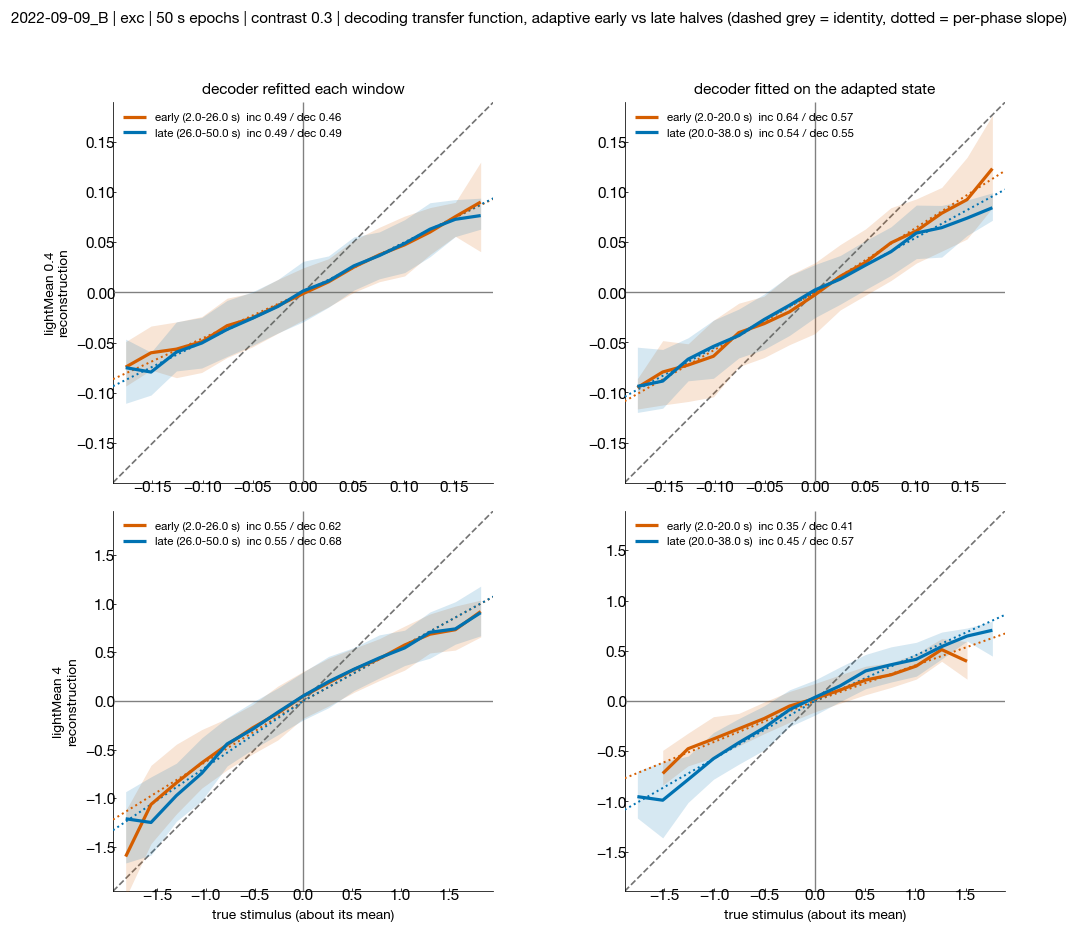

In [7]:
reconstruction_by_condition = vmn.add_early_late_reconstruction(
    reconstruction_by_condition)


## 5. Save this cell using the batch output format

Run after Sections 2–4 (including any desired early/late analysis). This uses the **same save function as Section 6**, without repeating raw-data loading or fitting. It saves into `SAVE_OUTPUT_DIR/<experiment>__<cell>/`:

- One HDF5 per recording type × duration × contrast × block set, with LN/decoding tables, adjusted stimulus/response sequences for later LNK, baseline-shift provenance, and epoch exclusions.
- The existing raw, static LN, temporal LN, and decoding figures under `figures/`.
- Selection/QC tables, saved-condition index, and figure manifest under `tables/`.
- `run_manifest.json` containing the cell identity, actual interactive settings, and saved file paths.

The result is directly available in the inspection browser, Section 6c population analysis, and the index-based LNK loader. Rerunning Section 5 or Section 6 for the same condition updates the same file in the same cell folder. Keep/Remove and Example decisions are preserved. Slow LNK fits/results are not run or saved here. The default population root is `/Volumes/ChrisNewSSD/retinanalysis_output/rod_adaptation/noise`.

Saved figures come from the completed in-memory results, even if their notebook display was closed. The saved baseline settings must agree with the completed whole-cell analysis; changing the controls after fitting requires rerunning the analysis first. Existing flat legacy files are left untouched.


In [ ]:
# Save the completed Sections 2-4 results using the same writer as batch Section 6.
SAVE_OUTPUT_DIR = vmn.condition_output_dir()  # population root; cell subfolder is automatic
SAVE_FIGURE_DPI = 300
save_settings = vmn.CellAnalysisSettings(
    max_epochs=MAX_EPOCHS, min_epochs_per_condition=MIN_EPOCHS_PER_CONDITION,
    recording_types_to_analyze=recording_types_to_analyze,
    epoch_index_ranges_by_rec_type=EPOCH_INDEX_RANGES_BY_REC_TYPE,
    remove_mean_condition=remove_mean_condition, remove_epochs=REMOVE_EPOCHS,
    force_spike_flag=forceSpikeFlag, force_whole_cell_flag=forceWholeCellFlag,
    whole_cell_rec_type=WHOLE_CELL_REC_TYPE,
    align_epoch_means=ALIGN_WHOLE_CELL_BASELINE_WITHIN_MEAN,
    whole_cell_baseline_target=WHOLE_CELL_BASELINE_TARGET,
    whole_cell_baseline_shift_pa=WHOLE_CELL_BASELINE_SHIFT_PA,
    spike_median_window_ms=SPIKE_MEDIAN_WINDOW_MS,
    spike_high_pass_hz=SPIKE_HIGH_PASS_HZ, psth_sigma_ms=SPIKE_PSTH_SIGMA_MS,
    whole_cell_bin_ms=WHOLE_CELL_BIN_MS,
    min_firing_rate_hz=MIN_FIRING_RATE_HZ,
    min_whole_cell_modulation_pa=MIN_WHOLE_CELL_MODULATION_PA,
    low_response_epoch_fraction=LOW_RESPONSE_EPOCH_FRACTION,
    skip_seconds=SKIP_SECONDS, downsample=DOWNSAMPLE, mean_window_s=MEAN_WINDOW_S,
    condition_window_s=WINDOW_SECONDS, temporal_window_s=TEMPORAL_WINDOW_S,
    max_series_resistance=MAX_SERIES_RESISTANCE,
    decode_skip_s=DECODE_SKIP_S, decode_window_s=DECODE_WINDOW_S,
    decode_window_candidates_s=DECODE_WINDOW_CANDIDATES_S,
    decode_bin_ms=DECODE_BIN_MS, steady_state_s=STEADY_STATE_S,
    min_phase_ms=MIN_PHASE_MS,
    direction_min_change_quantile=DIRECTION_MIN_CHANGE_QUANTILE,
    trace_seconds=TRACE_SECONDS, figure_dpi=SAVE_FIGURE_DPI)

saved_cell_run = vmn.save_cell_analysis_run(
    CELL_INDEX, protocol_cells, protocol_blocks, settings=save_settings,
    epoch_table=epoch_table, inspection=inspection,
    core_by_condition=core_by_condition,
    reconstruction_by_condition=reconstruction_by_condition,
    raw_figures=raw_trace_figures_by_assigned_type,
    output_dir=SAVE_OUTPUT_DIR)
saved_condition_outputs = saved_cell_run.saved_condition_outputs
print(f'Saved cell output: {saved_cell_run.output_dir}')
display(saved_condition_outputs)


### 5a. Saved-cell summary

Briefly confirm the saved cells and example selections. Full figure browsing, Keep/Remove and Example controls, and batch-selection CSV export are in Section 6a.

The static-LN prediction R² histogram compares each condition's lowest and highest mean light levels, with recording types shown separately. Set `SAVED_ONLY_KEPT=True` to show only retained cell/recording-type pairs, or False for all saved cells. Use `SAVED_CELL_INDICES` to restrict either view to specific indices (None, one integer, a tuple, or a range). The summary and R² plot use the same selection. The plot counts each fit once, retains negative R², and reports missing values. This uses the complete LN prediction score (`r2`), not the sigmoid-fit score (`nl_r2`).


Saved-cell view: Keep selections only | requested indices: None
97 saved cell(s), 167 condition(s); 97 kept cell(s)
Example cell indices: (0, 2, 3, 4)
Saved output: /Volumes/ChrisNewSSD/retinanalysis_output/rod_adaptation/noise


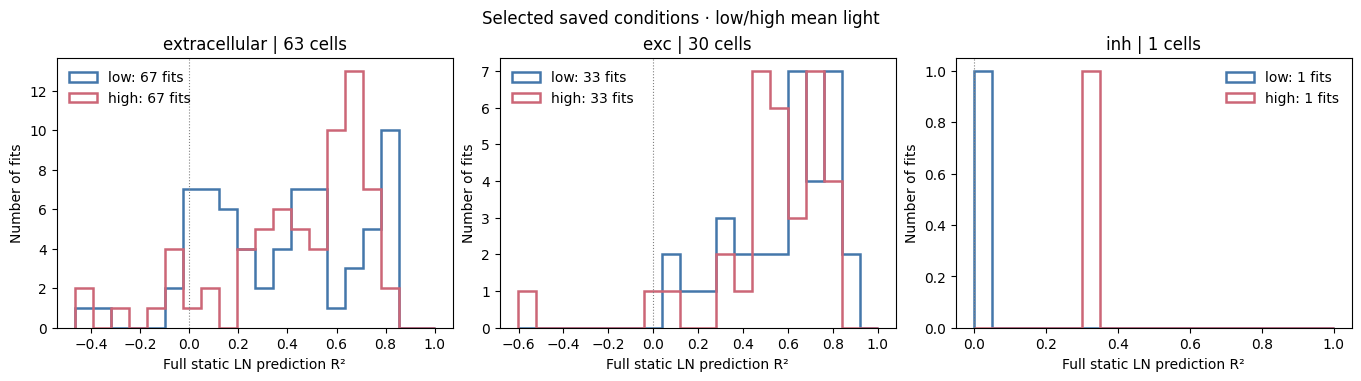

In [4]:
SAVED_REVIEW_OUTPUT_DIR = vmn.condition_output_dir()
SAVED_ONLY_KEPT = True  # show only cell/recording-type pairs marked Keep in Section 6
SAVED_CELL_INDICES = None  # optional subset: one index, (0, 7, 12), or range(...); None = all
saved_cells = vmn.saved_cell_review_flags(
    vmn.load_condition_index(output_dir=SAVED_REVIEW_OUTPUT_DIR, protocol_cells=protocol_cells),
    output_dir=SAVED_REVIEW_OUTPUT_DIR)
if SAVED_ONLY_KEPT:
    saved_cells = saved_cells.loc[saved_cells.keep].copy()
if SAVED_CELL_INDICES is not None:
    selected_indices = vmn.normalize_cell_indices(SAVED_CELL_INDICES)
    selected_identities = protocol_cells.loc[
        protocol_cells.cell_index.isin(selected_indices), ['exp_name', 'cell_label']]
    selected_identities = selected_identities.rename(columns={'exp_name': 'date'}).drop_duplicates()
    saved_cells = saved_cells.merge(selected_identities, on=['date', 'cell_label'], how='inner')
print('Saved-cell view:', 'Keep selections only' if SAVED_ONLY_KEPT else 'all saved cells',
      '| requested indices:', SAVED_CELL_INDICES)
saved_count = len(saved_cells[['date', 'cell_label']].drop_duplicates())
kept_count = len(saved_cells.loc[saved_cells.keep, ['date', 'cell_label']].drop_duplicates())
example_indices = tuple(sorted(int(index) for index in
    saved_cells.loc[saved_cells.is_example, 'cell_index'].dropna().unique()))
print(f'{saved_count} saved cell(s), {len(saved_cells)} condition(s); {kept_count} kept cell(s)')
print('Example cell indices:', example_indices)
print('Saved output:', SAVED_REVIEW_OUTPUT_DIR)

# Full static LN prediction R²; one fit per saved condition and light mean.
static_ln_quality = vmn.saved_static_ln_quality(SAVED_REVIEW_OUTPUT_DIR)
if not static_ln_quality.empty:
    selected_modes = saved_cells[['date', 'cell_label', 'rec_type']].drop_duplicates()
    static_ln_quality = static_ln_quality.merge(
        selected_modes, on=['date', 'cell_label', 'rec_type'], how='inner')
static_r2_figure = vmn.plot_saved_static_ln_r2(static_ln_quality)
if static_r2_figure is not None:
    static_r2_figure.suptitle('Selected saved conditions · low/high mean light')
    display(static_r2_figure)
    plt.close(static_r2_figure)
else:
    print('No saved low/high static LN R² values found.')


## 6. Batch Sections 2–5 over selected cell indices

Run the complete selection/QC, core LN, reconstruction, and HDF5-export workflow for each selected stable cell index. Set `BATCH_CELL_INDICES` to one integer (for example, `1`) or to a `range`, list, or tuple for a batch. Run this cell directly after the import cell; Sections 1–5 are not required. Metadata is loaded internally using the stable cell-index registry and recording-mode cache. Known selections query only their recording dates; missing or outdated mode-cache entries trigger the same classifier/parser refresh as Section 1. Set `BATCH_CELL_INDICES = None` for all eligible cells, or enable `LOAD_BATCH_SELECTION_CSV` to use the saved Keep selection. Each cell is isolated: a failure is printed and recorded in `batch_summary.csv`, then the next index runs. Figures are saved and closed without being displayed.

Outputs are grouped under `retinanalysis_output/rod_adaptation/noise/<date>__<cell>/`: compact population `.h5` files at the cell-folder root, all current §2–4 plots in `figures/`, selection/QC tables in `tables/`, and `run_manifest.json`. Use `BATCH_OVERRIDES_BY_INDEX` only for cell-specific corner cases such as manual epoch routing, exclusions, or a whole-cell all-epoch baseline shift (for example, `{'whole_cell_baseline_shift_pa': 3000.0}`).

In [4]:
# Standalone after the import cell.
vmn = importlib.reload(vmn)

# One integer runs one cell; range/list/tuple run multiple cells.
# BATCH_CELL_INDICES = None  # all eligible cells; no Section 1 required
BATCH_CELL_INDICES = 5
BATCH_OUTPUT_DIR = vmn.condition_output_dir()  # ChrisNewSSD rod/noise output
LOAD_BATCH_SELECTION_CSV = False  # True: use Keep selections exported by Sections 5a/6a
BATCH_SELECTION_CSV = BATCH_OUTPUT_DIR / 'kept_cell_selection.csv'
REFRESH_BATCH_MODE_CACHE = False  # reuse valid recording-type cache
LOAD_SAVED_BASELINE_ADJUSTMENTS = True  # restore saved shift, alignment, and target per cell
# Baseline authority: each cell's tables/saved_conditions.csv; older CSVs use their listed HDF5.
BATCH_TEMPORAL_N_WINDOWS = 5  # 60-second conditions use 6; other durations use this count
# Missing saved correction: zero pA. Explicit per-index overrides take precedence.
# Fit outputs are updated in place; example and Keep/Remove flags are preserved.
# Window duration = (epoch duration - skip_seconds) / count (6 for 60-second epochs).
# Section 6c aligns saved windows 1-5 by order across all recordings >=50 s.
RUN_BATCH = True  # review the range/overrides, then set True

BATCH_SETTINGS = vmn.CellAnalysisSettings(
    max_epochs=None, min_epochs_per_condition=5,
    recording_types_to_analyze=('extracellular', 'exc', 'inh'),
    # Full-epoch spike detection -> 10 ms Gaussian sigma -> downsample.
    spike_median_window_ms=10.0, spike_high_pass_hz=300.0,
    psth_sigma_ms=10.0, whole_cell_bin_ms=5.0,
    align_epoch_means=True, whole_cell_baseline_target='median',
    whole_cell_baseline_shift_pa=0.0,
    skip_seconds=1.0, downsample=1, mean_window_s=5.0,
    condition_window_s=15.0, temporal_n_windows=BATCH_TEMPORAL_N_WINDOWS,
    max_series_resistance=30e6, decode_skip_s=2.0,
    decode_window_s='auto', decode_window_candidates_s=(1., 2., 3., 4., 5.),
    decode_bin_ms=10.0, steady_state_s=10.0, min_phase_ms=20.0,
    direction_min_change_quantile=0.2, trace_seconds=(20.0, 30.0))

BATCH_OVERRIDES_BY_INDEX = {
    5: {
    #     'epoch_index_ranges_by_rec_type': {
    #         'extracellular': range(0, 14), 'exc': range(14, 35)},
     'remove_mean_condition': (0.08,0.8),
        'remove_epochs': (1,),
    #     'whole_cell_baseline_shift_pa': 3000.0,
    },
}

# Optional metadata correction. Use existing saved-name style, for example:
# 'ON-parasol', 'OFF-parasol', 'ON-midget', or 'OFF-midget'.
BATCH_CELL_TYPE_OVERRIDES = {
     22: 'ON-midget',
}

batch_inputs = vmn.load_batch_inputs(
    BATCH_CELL_INDICES,
    selection_path=BATCH_SELECTION_CSV if LOAD_BATCH_SELECTION_CSV else None,
    refresh_mode_cache=REFRESH_BATCH_MODE_CACHE)
SELECTED_BATCH_CELL_INDICES = batch_inputs['cell_indices']
if LOAD_BATCH_SELECTION_CSV:
    kept_mode_overrides = batch_inputs['kept_mode_overrides']
    # Only kept modes run; intersect any additional manual mode restriction.
    BATCH_OVERRIDES_BY_INDEX = {index: {
        **BATCH_OVERRIDES_BY_INDEX.get(index, {}),
        'recording_types_to_analyze': tuple(mode for mode in kept['recording_types_to_analyze']
            if mode in BATCH_OVERRIDES_BY_INDEX.get(index, {}).get(
                'recording_types_to_analyze', BATCH_SETTINGS.recording_types_to_analyze))}
        for index, kept in kept_mode_overrides.items()}
print('Batch cell indices:', SELECTED_BATCH_CELL_INDICES)
if RUN_BATCH and SELECTED_BATCH_CELL_INDICES:
    batch_summary = vmn.run_cell_analysis_batch(
        SELECTED_BATCH_CELL_INDICES, batch_inputs['protocol_cells'],
        batch_inputs['protocol_blocks'], batch_inputs['block_modes'],
        settings=BATCH_SETTINGS,
        load_saved_baseline_adjustments=LOAD_SAVED_BASELINE_ADJUSTMENTS,
        overrides_by_index=BATCH_OVERRIDES_BY_INDEX,
        cell_type_overrides_by_index=BATCH_CELL_TYPE_OVERRIDES,
        output_dir=BATCH_OUTPUT_DIR,
        continue_on_error=True)
    display(batch_summary)
else:
    print(f'batch ready for {len(SELECTED_BATCH_CELL_INDICES)} cell index(es) '
          f'{SELECTED_BATCH_CELL_INDICES}; set RUN_BATCH = True to start')


Batch cell indices: (5,)
batch output: /Volumes/ChrisNewSSD/retinanalysis_output/rod_adaptation/noise
[1/1] cell index 5: starting Sections 2--5
  baseline +300 pA (saved whole-cell baseline policy); temporal windows: 5 (count), None s (legacy target)


/Users/chrischen/Documents/GitHub/retinanalysis/SingCellNotebooks/rodAdaptation/variable_mean_noise.py:9562: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.98))


/Users/chrischen/Documents/GitHub/retinanalysis/SingCellNotebooks/rodAdaptation/variable_mean_noise.py:9562: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.98))


/Users/chrischen/Documents/GitHub/retinanalysis/SingCellNotebooks/rodAdaptation/variable_mean_noise.py:5596: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(len(means), len(modes), figsize=figsize, squeeze=False)


[1/1] cell index 5: complete | 2 condition(s), 22 figure(s) | 146.8 s
batch finished: 1/1 cells complete | /Volumes/ChrisNewSSD/retinanalysis_output/rod_adaptation/noise/batch_summary.csv


,cell_index,date,cell_label,status,n_conditions,n_figures,elapsed_s,output_dir,error,whole_cell_baseline_shift_pa,baseline_source,baseline_source_paths,temporal_window_s,temporal_n_windows
0,5,2020-06-16_B,Cell3,complete,2,22,146.767067,/Volumes/ChrisNewSSD/retinanalysis_output/rod_...,,300.0,saved whole-cell baseline policy,/Volumes/ChrisNewSSD/retinanalysis_output/rod_...,None,5


### 6a. Processed-trace and saved-figure inspector

Run directly after the import cell; cell identities are loaded from saved outputs. Select a cell and recording type to inspect one processed trace alongside saved LN, temporal LN, and decoding figures.

All panels load PNGs saved by the bulk run. The processed-trace panel uses the Section 2 `section2__raw-<rec_type>.png` files: the legacy “raw” filename contains preprocessed traces. Their preprocessing and display settings are the ones used during that saved run (including any display downsampling).

The inspector does not load amplifier data, reprocess traces, or render figures. If a saved PNG is missing, its panel shows “not available”; rerun and save the relevant analysis to create it. Rerun this section to reload the browser code and saved-figure index.

`REVIEW_ONLY_KEPT` and `REVIEW_CELL_INDICES` control which cells appear. The **Cell type** and **Recording type** dropdowns further filter that selection together; **All** removes the corresponding filter. Recording type shows only cells with that saved recording and keeps the displayed recording on that type while browsing. Filters use saved metadata and do not change Keep or Example flags. **Keep** / **Remove** apply to the selected cell × recording type; **Set example** / **Unset example** also apply only to the selected cell × recording type, independently of Keep. Legacy cell-level Example flags carry over to each saved recording type until edited separately.


In [ ]:
# Refresh the browser implementation when rerunning this section.
for module_name in ('retinanalysis.utils.spike_detector',
                    'retinanalysis.SCutils.trace_processing',
                    'retinanalysis.utils.browse'):
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])
vmn = importlib.reload(vmn)

REVIEW_OUTPUT_DIR = vmn.condition_output_dir()
REVIEW_ONLY_KEPT = True  # False includes cells that have not been selected with Keep
REVIEW_CELL_INDICES = None  # None, one integer, or a list/tuple/range of cell indices
# Cell type and Recording type further narrow this selection using the loaded index.

review_indices = REVIEW_CELL_INDICES
if REVIEW_ONLY_KEPT:
    kept_indices = vmn.high_quality_cell_indices(REVIEW_OUTPUT_DIR)
    review_indices = (kept_indices if review_indices is None else tuple(
        index for index in vmn.normalize_cell_indices(review_indices)
        if index in kept_indices))

# Each review action updates kept_cell_selection.csv; rerun to refresh the filter.
cell_review_browser = None
if review_indices is not None and not vmn.normalize_cell_indices(review_indices):
    print('No cells match the review selection. Adjust REVIEW_CELL_INDICES '
          'or set REVIEW_ONLY_KEPT = False to review all saved cells.')
else:
    cell_review_browser = vmn.build_cell_review_browser(
        cell_indices=review_indices, output_dir=REVIEW_OUTPUT_DIR, processed_traces=True)
    display(cell_review_browser)


### 6b. MATLAB reference dates: analysis coverage

Start from every entry in `rodVariableMeanNoise.mat`. The date summary always includes every MATLAB date, even when no analysis exists or a cell-type filter is active. **MATLAB date** is the date stored in the `.mat`; **Corrected date** is MATLAB date + 2 days. Recorded-date fallbacks remain explicit.

**Missing date** means no saved analysis exists for the corrected date and no reference entry matched via the recorded-date fallback. **No matching entries** means that date has saved analysis, but none matches the reference cells, recording types, and durations. **Partial coverage** means some reference entries are missing. **All entries found** means every reference entry has saved analysis; cell-type disagreements are counted separately.

Counts are MATLAB entries, counted once even when multiple saved contrasts match. **Kept (CSV)** shows how many matched reference entries are retained in the review CSV; an analyzed but unkept entry is not missing analysis. Repeated entries in the MATLAB file retain their original MATLAB index.

The **Cell type** dropdown filters only the detailed reference rows below the full date summary, matching either reference or saved annotations. Each detail group shows the original MATLAB date and its corrected date. **All** restores every reference entry.


In [ ]:
# Standalone after the import cell.
vmn = importlib.reload(vmn)
QUALITY_OUTPUT_DIR = vmn.condition_output_dir()
roster = vmn.load_summary(show=False)
all_saved_conditions = vmn.load_condition_index(QUALITY_OUTPUT_DIR)
high_quality_cells = vmn.load_high_quality_cells(QUALITY_OUTPUT_DIR)
HIGH_QUALITY_CELL_INDICES = vmn.high_quality_cell_indices(QUALITY_OUTPUT_DIR)
matlab_saved_comparison = vmn.compare_matlab_roster_to_saved(
    roster, all_saved_conditions, show=False)

# Every date comes from the MATLAB file; keep this overview unfiltered.
matlab_date_coverage = vmn.summarize_matlab_date_coverage(
    matlab_saved_comparison, all_saved_conditions, high_quality_cells)
missing_matlab_dates = matlab_date_coverage.loc[
    matlab_date_coverage.status.eq('Missing date')].copy()
print(f'Reference: {vmn.summary_path()}')
print(f'Keep CSV: {vmn.high_quality_cells_path(QUALITY_OUTPUT_DIR)}')
print(f'{len(matlab_date_coverage)} MATLAB dates | '
      f'{len(missing_matlab_dates)} missing analysis dates | '
      f'{matlab_date_coverage.missing_entries.sum()} unmatched MATLAB entries | '
      f'{matlab_date_coverage.kept_entries.eq(0).sum()} dates with no matched entry in Keep CSV')
coverage_table = matlab_date_coverage.rename(columns={
    'matlab_date': 'MATLAB date', 'corrected_date': 'Corrected date',
    'saved_dates': 'Saved analysis dates', 'status': 'Coverage',
    'matlab_entries': 'MATLAB entries', 'matched_entries': 'Found',
    'missing_entries': 'Missing', 'kept_entries': 'Kept (CSV)',
    'type_disagreements': 'Check type', 'fallback_entries': 'Date fallback'})
display(coverage_table.style.map(
    lambda value: {'Missing date': 'background-color: #fce8e6; color: #a50e0e',
                   'No matching entries': 'background-color: #fce8e6; color: #a50e0e',
                   'Partial coverage': 'background-color: #fef7e0; color: #7a4f00',
                   'All entries found': 'background-color: #e6f4ea; color: #137333'}.get(value, ''),
    subset=['Coverage']).map(
    lambda value: 'background-color: #fef7e0; color: #7a4f00' if value == 0 else '',
    subset=['Kept (CSV)']).hide(axis='index').format(na_rep='—', escape='html'))

match_rows = matlab_saved_comparison.copy()
kept_keys = set(zip(high_quality_cells.date.astype(str),
                    high_quality_cells.cell_label.astype(str),
                    high_quality_cells.rec_type.astype(str)))
match_rows['status'] = [
    'Not matched' if row.match_status == 'not matched' else
    'Check cell type' if row.match_status == 'candidate' else
    'Matched' if (str(row.saved_date), str(row.saved_cell_label),
                  str(row.saved_rec_type)) in kept_keys else 'Saved, not kept'
    for row in match_rows.itertuples()]
match_rows['saved_index'] = match_rows.saved_cell_index.where(
    match_rows.saved_cell_index.ge(0)).astype('Int64')
match_rows['date_note'] = match_rows.saved_date.where(
    match_rows.date_match_source.eq('recorded-date fallback'), '')
match_rows = match_rows.rename(columns={
    'matlab_cell_label': 'cell', 'matlab_rec_type': 'recording',
    'matlab_epoch_seconds': 'duration_s', 'date_note': 'fallback_date'})
match_columns = ['matlab_index', 'cell', 'recording', 'duration_s', 'status',
                 'matlab_cell_type', 'saved_cell_type', 'saved_index', 'fallback_date']
# Normalize aliases; prefer the saved spelling when both annotations agree.
type_labels = {}
for column in ('matlab_cell_type', 'saved_cell_type'):
    for label in match_rows[column].dropna().astype(str):
        if label.strip():
            type_labels[vmn._normalize_cell_type(label)] = label
quality_cell_type_selector = widgets.Dropdown(
    options=[('All', None)] + sorted(((label, key) for key, label in type_labels.items())),
    description='Cell type:', layout=widgets.Layout(width='320px'))
quality_match_tables = widgets.HTML()

def show_quality_matches(_change=None):
    selected = vmn.filter_matlab_saved_comparison_cell_types(
        match_rows, quality_cell_type_selector.value)
    parts = []
    for date, date_rows in selected.groupby('recorded_date', sort=True):
        date_rows = date_rows.sort_values(['cell', 'recording', 'duration_s'])
        date_table = date_rows[match_columns].drop_duplicates().reset_index(drop=True)
        if not date_table.fallback_date.any():
            date_table = date_table.drop(columns='fallback_date')
        date_table = date_table.rename(columns={
            'matlab_index': 'MATLAB index',
            'matlab_cell_type': 'reference type', 'saved_cell_type': 'saved type'})
        styled = date_table.style.map(
            lambda value: {'Not matched': 'background-color: #fce8e6; color: #a50e0e',
                           'Check cell type': 'background-color: #fef7e0; color: #7a4f00',
                           'Saved, not kept': 'background-color: #fef7e0; color: #7a4f00',
                           'Matched': 'background-color: #e6f4ea; color: #137333'}.get(value, ''),
            subset=['status']).hide(axis='index').format(na_rep='—', escape='html')
        heading = (f'MATLAB date {date} | corrected date '
                   f'{date_rows.corrected_date.iloc[0]}')
        parts.append('<h4>' + html.escape(heading) + '</h4>' + styled.to_html())
    quality_match_tables.value = (''.join(parts) if parts else
        'No MATLAB reference cells match this cell-type filter.')

quality_cell_type_selector.observe(show_quality_matches, names='value')
show_quality_matches()
display(widgets.VBox([quality_cell_type_selector, quality_match_tables]))


### 6c. High-quality population LN curves and parameter changes

Quality selection: `POPULATION_QUALITY_MODE='csv'` uses the existing Keep list; `'r2'` selects using static LN prediction quality independently of Keep/Remove; `'both'` requires both. `STATIC_LN_R2_THRESHOLD=0.4` requires the low and high static fit scores to be strictly greater than 0.4. Each duration/contrast/recording-type condition is tested separately, before loading its temporal curves. Missing/nonfinite scores fail the R² test. `population_quality_audit` records both scores and each inclusion decision. These controls never modify the review CSVs or Example flags.

Temporal curves and parameters align the first five saved windows by order across all recordings lasting at least 50 s (including 50.5, 55, and 56 s). Shared display midpoints are 5.9, 15.7, 25.5, 35.3, and 45.1 s (the 50 s reference with a 1 s onset skip). This is approximate ordinal alignment, with no refitting or temporal interpolation. The entire fifth window is retained even when its original end exceeds 50 s; a sixth window is excluded. Original labels, bounds, and midpoints remain in `population_time_alignment`. Thirty-second recordings remain excluded from temporal LN plots.
Temporal NL overlays evaluate the saved sigmoid parameters by default (`FITTED_TEMPORAL_NL=True`); empirical bin means remain available with False. Parameter lines connect only unchanged condition cohorts, so changes in contributing cells do not imply a within-cell jump.

Standalone after imports: reload the visual-review CSV and saved HDF5 tables. Static LN curves pool **all contrasts and durations** (including 30, 50, 50.5, 55, 56, and 60 s). Temporal curves and parameters use **all recordings lasting at least 50 s**, pooling contrasts by saved window order (first through fifth). Low/high refers to each condition's lowest/highest light mean. Cell type, recording type, and photopic/scotopic classification remain separate; each physical cell contributes once per coordinate before population mean ± SEM. Counts report static and temporal contributors separately.

`NORMALIZED_LN=True` normalizes temporal nonlinearities separately for low and high light within each saved condition, using one response scale across all retained windows. Spike scale is the maximum y response; whole-cell scale is the maximum absolute y response, preserving the negative excitatory-current sign. Static nonlinearities also use separate low/high response scales. Filters retain their saved amplitudes, matching the per-cell LN plots; no peak normalization is applied to static or temporal filters. `NORMALIZED_LN` affects only nonlinearity y-values and response-related parameters. Set `NORMALIZED_LN=False` to show absolute responses and temporal parameters.

The saved generator x-values are used directly in their original contrast units, with no normalization; nonlinearities are displayed from **−1 to 1**, without stretching different contrasts onto the same range or extrapolating beyond saved support. Normalization scales are calculated before this display restriction. For `y = α Φ(βx + γ) + ε` and response scale `S`, normalized amplitude is `α/S`, baseline is `ε/S`, and β and γ are unchanged. The signed midpoint slope is `αβ/√(2π)` and is divided by `S`; both β (steepness) and this response slope are plotted. Temporal parameter windows are combined according to `TEMPORAL_PARAMETER_WINDOW_COMBINE`.

**Saved baseline adjustment:** Whole-cell shifts were applied before fitting and are already present in saved NL y-values and ε. Section 6c never adds them again; missing saved shift metadata means 0 pA. The audit below lists the saved shift for every selected condition. An additive y-shift changes ε only, leaving α, β, γ, filter shape, and absolute slope unchanged. Subsequent response normalization uses the adjusted y-values: its divisor may change, so normalized α, ε, and response slope can change accordingly. `NORMALIZED_LN=False` shows the absolute parameters.

Older files without contrast metadata are excluded when a contrast-resolved replacement exists for the identical experiment, cell, recording type, duration, and block set. The source audit lists these superseded files; distinct contrasts and block sets remain separate. No saved files are modified.


**Decoding dynamics:** Gain, direction accuracy, and normalized error now also show first/second/last increment–decrement contrasts and paired last-minus-second changes (mean ± SEM with cell points). `DECODING_DYNAMICS_WINDOWS` defaults to target intervals 1–10, 10–20, and 40–50 s, for all recordings lasting at least 50 s. Decoder bins retain their actual time support; ordinal alignment applies to temporal LN windows. Only whole saved decoder bins inside each interval contribute. The saved decoding starts at 2 s, so the first target interval has incomplete coverage; boundary-crossing bins are excluded. `population_decoding_window_audit` reports actual support and exclusions. The time course uses the same conditions at all three times; the primary second-to-last comparison uses conditions present at both times. Normalization is retained; accuracy is displayed in percentage points.


In [ ]:
# Standalone after the import cell: reload the visual-review CSV and saved HDF5.
vmn = importlib.reload(vmn)  # use current plotting code even in an existing notebook session
POPULATION_OUTPUT_DIR = vmn.condition_output_dir()
POPULATION_REC_TYPES = ('extracellular', 'exc')
POPULATION_CELL_TYPES = ('ON-parasol', 'ON-midget')
POPULATION_QUALITY_MODE = 'csv'  # 'csv': Keep list; 'r2': static R² only; 'both': require both
STATIC_LN_R2_THRESHOLD = 0.4  # both low/high static prediction R² must be strictly greater
PHOTOPIC_TIME_TO_PEAK_THRESHOLD_MS = 20.0
TEMPORAL_PARAMETER_WINDOW_COMBINE = 1
POPULATION_CURVE_GRID_POINTS = 101
NORMALIZED_LN = True  # False: absolute LN responses and parameter values
FITTED_TEMPORAL_NL = True  # overlay the saved sigmoid fits; False shows empirical NL bin means
DECODING_DYNAMICS_WINDOWS = ((1., 10.), (10., 20.), (40., 50.))  # first, second, last within first 50 s
DECODING_DYNAMICS_DURATIONS = None  # all durations >=50 s; optional explicit tuple
LN_OVERLAY_MODE = 'population'  # 'population' or 'example'
LN_OVERLAY_EXAMPLE_INDICES = ()  # one retained cell per class for example mode
if LN_OVERLAY_MODE not in ('population', 'example'):
    raise ValueError('LN_OVERLAY_MODE must be population or example')

population_ln = vmn.high_quality_population_ln_analysis(
    rec_types=POPULATION_REC_TYPES, cell_types=POPULATION_CELL_TYPES,
    quality_selection=POPULATION_QUALITY_MODE, static_r2_threshold=STATIC_LN_R2_THRESHOLD,
    fitted_temporal_nl=FITTED_TEMPORAL_NL,
    photopic_time_to_peak_threshold_ms=PHOTOPIC_TIME_TO_PEAK_THRESHOLD_MS,
    temporal_parameter_window_combine=TEMPORAL_PARAMETER_WINDOW_COMBINE,
    output_dir=POPULATION_OUTPUT_DIR,
    grid_points=POPULATION_CURVE_GRID_POINTS, normalized_ln=NORMALIZED_LN,
    retain_normalized=(LN_OVERLAY_MODE == 'example'))

population_source_audit = population_ln['source_audit']
population_quality_audit = population_ln['quality_selection_audit']
print('Population quality mode:', POPULATION_QUALITY_MODE, '| static R² threshold:', STATIC_LN_R2_THRESHOLD)
if not population_quality_audit.empty:
    print(f'{int(population_quality_audit.included.sum())}/{len(population_quality_audit)} saved conditions selected')
    display(population_quality_audit.groupby(['cell_type', 'rec_type', 'included']).size().rename('n_conditions').reset_index())
superseded_sources = population_source_audit.loc[~population_source_audit.included]
if not superseded_sources.empty:
    print('Older outputs excluded from population analysis (see reason; current saved-run CSV takes precedence):')
    display(superseded_sources)

population_baseline_audit = population_ln['baseline_adjustment_audit']
print('Saved baseline shifts already included in NL curves and epsilon (no second shift):')
display(population_baseline_audit[[
    'cell_index', 'date', 'cell_label', 'rec_type', 'stim_seconds',
    'light_contrast', 'whole_cell_baseline_shift_pa', 'baseline_status',
    'static_included', 'temporal_included']])

population_curve_counts = population_ln['condition_counts']
population_temporal_counts = population_ln['temporal_condition_counts']
population_time_alignment = population_ln['temporal_time_alignment_audit']
if not population_time_alignment.empty:
    print('Approximate ordinal alignment: first through fifth saved window; no refitting.')
    display(population_time_alignment.groupby(['stim_seconds', 'order']).agg(
        original_midpoint_min_s=('original_centre_s', 'min'),
        original_midpoint_max_s=('original_centre_s', 'max'),
        display_midpoint_s=('centre_s', 'first'),
        n_conditions=('condition_id', 'nunique'),
        n_cells=('cell_index', 'nunique')).reset_index())
print('Temporal x-axis: approximate 50 s reference midpoints; original times remain in population_time_alignment.')
print('30 s recordings contribute to static analysis only, never temporal LN population plots.')
print('Static low/high condition pairs contributing to §6c:')
display(population_curve_counts)
print('Temporal low/high condition pairs: >=50 s recordings, saved windows 1-5:')
display(population_temporal_counts)

current_figure_group = None
for figure_group, condition, figure in vmn.iter_population_ln_figures(
        population_ln):
    if figure_group != current_figure_group:
        print(f'\n{figure_group}')
        current_figure_group = figure_group
    print(condition)
    display(figure)
    plt.close(figure)

print('Adaptation selectivity visualizations (exploratory; choose figures later):')
for figure_name, figure in vmn.iter_population_class_overlay_figures(
        population_ln, example_cell_indices=(
            LN_OVERLAY_EXAMPLE_INDICES if LN_OVERLAY_MODE == 'example' else None)):
    print(figure_name)
    display(figure)
    plt.close(figure)
population_decoding_dynamics = vmn.population_directional_decoding_dynamics(
    population_ln.get('directional_decoding', pd.DataFrame()),
    windows=DECODING_DYNAMICS_WINDOWS, durations=DECODING_DYNAMICS_DURATIONS)
population_ln['directional_decoding_dynamics'] = population_decoding_dynamics
population_decoding_window_audit = population_decoding_dynamics['audit']
population_decoding_changes = population_decoding_dynamics['changes']
print('Decoding dynamics: first, second, last target intervals:', DECODING_DYNAMICS_WINDOWS)
print('Primary comparison: last minus second, paired within condition before averaging within cell.')
print('Uses whole saved decoder bins within each interval; boundary-crossing bins are excluded.')
print('Accuracy uses change-count weights; gain/error are means of saved local estimates.')
if not population_decoding_window_audit.empty:
    display(population_decoding_window_audit.groupby(
        ['rec_type', 'mode', 'stage', 'status'], dropna=False
    ).size().rename('n_conditions').reset_index())
    coverage = population_decoding_window_audit.query('n_bins > 0')
    if not coverage.empty:
        display(coverage.groupby(['rec_type', 'mode', 'stage'], dropna=False).agg(
            earliest_start_s=('actual_start_s', 'min'),
            latest_start_s=('actual_start_s', 'max'),
            earliest_end_s=('actual_end_s', 'min'),
            latest_end_s=('actual_end_s', 'max'),
            min_coverage=('coverage_fraction', 'min'),
            max_coverage=('coverage_fraction', 'max')).reset_index())
    print('Partial coverage is not an exact full-interval estimate. In existing saves, decoding starts at 2 s; 1–2 s is unavailable.')
    print('Steady-state decoders omit their training interval; conditions without last-window estimates cannot enter the paired comparison.')

for figure_name, figure in vmn.iter_population_adaptation_figures(population_ln):
    print(figure_name)
    display(figure)
    plt.close(figure)

directional_saturation = population_ln.get('directional_saturation_contrast', pd.DataFrame())
if not directional_saturation.empty:
    print('Matched positive-generator bright-light decoding: decrement minus increment')
    display(directional_saturation)


## 7. Select saved cells for LNK comparison

Choose ON-midget / ON-parasol cells and recording types before any traces are loaded or fitted. By default, use the recording-specific **Set example** selections from Section 6a, restricted to extracellular recordings. Set `LNK_CELL_INDICES` to an explicit index or list to override the Example selection. Cell-type and recording-type restrictions still apply. `None` with `LNK_USE_EXAMPLES=False` is rejected to prevent an accidental all-cell run.

This cell only previews the selection. Section 7a loads each selected cell's saved, baseline-adjusted inputs and fits the three one-state variants. Existing exclusions, alignment, onset skip, and preprocessing are retained. No raw traces are reprocessed and no baseline shift is applied twice.


In [ ]:
vmn = importlib.reload(vmn)
LNK_OUTPUT_DIR = vmn.condition_output_dir()
LNK_CELL_INDICES = None  # explicit integer/list overrides the Example selection
LNK_USE_EXAMPLES = True
LNK_CELL_TYPES = ('ON-midget', 'ON-parasol')
LNK_REC_TYPES = ('extracellular',)  # e.g. ('exc',), or None for all recording types

lnk_selection = vmn.select_saved_lnk_cells(
    cell_indices=LNK_CELL_INDICES, use_examples=LNK_USE_EXAMPLES,
    cell_types=LNK_CELL_TYPES, rec_types=LNK_REC_TYPES, output_dir=LNK_OUTPUT_DIR)
display(lnk_selection)
print(f'{lnk_selection.cell_index.nunique()} selected cells | '
      f'{lnk_selection.n_conditions.sum()} saved conditions')


## 7a. One-state LNK: compare gain, shift, and gain + baseline

Fit the same saved conditions with three mechanisms driven by one slow state, standardized as `a′`:

- **multiplicative:** `r = α exp(−k a′) Φ(βg + γ) + ε` — response gain / slope changes.
- **subtractive:** `r = α Φ(βg + γ − k a′) + ε` — the existing horizontal generator shift.
- **combined:** `r = α exp(−k a′) Φ(βg + γ) + ε + b a′` — gain / slope plus a vertical response-baseline shift. `b` has response units per SD of adaptation and may have either sign.

The combined model has eight core parameters versus seven for either original variant. It starts from the multiplicative training fit with `b=0`. Its extra parameter must improve the held-out score to win; training fit is not used to choose the preferred variant.

All three share the same prepared per-light-level filters, accepted samples, whole-epoch train/test split, warm-up exclusion, and optimization settings. The slow state uses stimulus drive only. Native sampling is retained. `r2_static` is the same cascade with adaptation disabled and the nonlinearity refitted. Scores hold out response epochs during the LNK optimization; the shared LN filter and initialization use the saved data, so these are conditional model comparisons, not fully nested validation of the entire LN/LNK pipeline.

The summary reports the best model and runner-up margin per condition and per cell. Only conditions with finite scores and converged fits for all three variants contribute to rankings. Conditions are averaged within each cell before the cell-type mean ± SEM, so each cell has equal weight. Recording types remain separate. The cell-type table reports model rank, mean held-out R², gain over the static baseline, number of cells, and number of cell-level wins. These describe the selected cells; small samples or small margins do not establish a general cell-type preference.

`LNK_SHOW_FIGURES=True` adds response fits, state trajectories, and nonlinearities for each variant. For combined fits, the conversion panel shows both gain and vertical offset. Results stay in `one_state_comparison`; the original HDF5 records and review CSVs are unchanged. Section 7b remains a separate optional two-state analysis.


In [ ]:
RUN_ONE_STATE = True
LNK_STATE_DT_MS = None  # native sample grid
LNK_TEST_FRACTION = 0.2
LNK_WARMUP_EPOCHS = 1
LNK_RESTARTS = 1
LNK_RANDOM_STATE = 0    # identical held-out epochs for all three variants
LNK_MAX_NFEV = 400
LNK_SHOW_FIGURES = False  # enable per-condition fits and nonlinearity snapshots
LNK_VIEW_S = (25.0, 95.0)
NL_WINDOWS = 5
NL_WARMUP_EPOCHS = 1

if RUN_ONE_STATE and not lnk_selection.empty:
    one_state_comparison = vmn.run_selected_one_state_lnk(
        lnk_selection, output_dir=LNK_OUTPUT_DIR, make_figures=LNK_SHOW_FIGURES,
        state_dt_ms=LNK_STATE_DT_MS, test_fraction=LNK_TEST_FRACTION,
        warmup_epochs=LNK_WARMUP_EPOCHS, n_restarts=LNK_RESTARTS,
        random_state=LNK_RANDOM_STATE, max_nfev=LNK_MAX_NFEV,
        view_s=LNK_VIEW_S, nl_windows=NL_WINDOWS,
        nl_warmup_epochs=NL_WARMUP_EPOCHS)
    lnk_fit_scores = one_state_comparison['scores']
    lnk_cell_winners = one_state_comparison['cell_winners']
    lnk_cell_type_summary = one_state_comparison['cell_type_summary']
    display(one_state_comparison['errors'])
    display(lnk_fit_scores)
    display(lnk_cell_winners)
    display(lnk_cell_type_summary)
else:
    one_state_comparison = {}
    lnk_fit_scores = pd.DataFrame()
    lnk_cell_winners = pd.DataFrame()
    lnk_cell_type_summary = pd.DataFrame()
    print('No fit run: enable RUN_ONE_STATE and select matching cells in Section 7.')


## 7b. LNK variant B — fast output state + slow pool, coupling **emergent**

Variant A asks *which* change fits better by building both in. This one builds in neither. It
restores the reference architecture: in `baccuslab/LNKS` the kinetics block **is** the output
stage (`v = X[1,:]`, the active state), and the nonlinearity only supplies its drive. Three
occupancies of one pool, summing to 1:

$$\frac{dA}{dt} = k_{act}\,u\,(1 - A - I) - k_{inact}A \qquad
  \frac{dI}{dt} = k_{slow,in}A - k_{slow,out}I \qquad r = \alpha A + \varepsilon$$

Gain is proportional to the resting occupancy $R = 1 - A - I$ (supplement eq 18), so sustained
drive fills the slow pool $I$ at $R$'s expense and the cell adapts. Nothing here says *how* the
input–output curve should change, so **whichever it does is a prediction** —
`vmn.apparent_nonlinearity` reads it back off the fitted model, which is the analogue of the
paper's Fig. 3A.

**Eight free parameters**, matching the combined one-state variant (the original gain-only and shift-only variants have seven): `alpha`/`epsilon` map occupancy into
response units, `beta`/`gamma` shape the drive, and four rate constants.

Three things worth knowing before reading the output:

- **The fast state is fitted as `tau_fast` and `occupancy`, not as two rate constants.** Only
  those combinations are identifiable. `k_act/k_inact` sets the active state's occupancy and
  their sum sets its speed, but past the sampling interval the sum stops mattering: scaling both
  by 20× holding the ratio moved held-out r² only 0.671 → 0.667 and left occupancy at 0.0555, so
  the optimiser drifted up that flat direction until `k_act` pinned at 2000/s. Changing the ratio
  alone has a real optimum. `tau_fast` is floored at the sampling interval — nothing faster is
  resolvable, and pushing well past it makes the relaxation underflow to NaN.

  **`tau_fast` then sits at that floor, and that is the result, not a defect.** The fast state
  wants to be instantaneous: the per-level temporal filter already carries all the fast dynamics,
  so the kinetics block has none left to contribute and reduces to an instantaneous rectification
  plus the slow pool. Whether the fast state earns its place is worth asking on other cells.
- **`alpha` is rate per unit occupancy, not a response range.** `A` peaks near 0.3–0.6, so the
  physiological ceiling is divided by that headroom or it binds for a units reason.
- **The integration marches, it does not iterate.** Each block solves `A` exactly with `I` fixed,
  then advances `I` from the block's mean `A`. An earlier sweep-the-whole-record scheme oscillated
  above `k_slow_in/k_slow_out ≈ 10`, which is where the data wants to go. Its error is block
  quantisation and falls with block size, which the tests check by refinement rather than by a
  chosen tolerance.

Read `r²` against `no depletion` — the same cascade with `k_slow_in = 0`, so the difference is
whether depletion is allowed at all. On 2020-06-11_B this scores 0.760 held out against variant
A's 0.761: the two architectures are equally good on this cell, and **neither is overfitting** —
both score higher held out than in sample.


In [ ]:
RUN_TWO_STATE = False     # set False to skip this section

TWO_STATE_DT_MS = 250.0   # block for the slow pool; error falls with it
TWO_STATE_RESTARTS = 2    # rate constants redrawn; the LN start is kept
TWO_STATE_TEST_FRACTION = 0.25

TWO_STATE_CELL_INDEX = None  # explicit cell from Section 7's selection
if RUN_TWO_STATE:
    if TWO_STATE_CELL_INDEX not in set(lnk_selection.cell_index):
        raise ValueError('Set TWO_STATE_CELL_INDEX to a cell in the Section 7 selection.')
    selected_modes = tuple(lnk_selection.loc[
        lnk_selection.cell_index.eq(TWO_STATE_CELL_INDEX), 'rec_type'].unique())
    reconstruction_by_condition, core_by_condition = vmn.load_saved_lnk_inputs(
        TWO_STATE_CELL_INDEX, output_dir=LNK_OUTPUT_DIR, rec_types=selected_modes,
        fit_static=False)
    two_state_by_condition = vmn.run_two_state_lnk_conditions(
        reconstruction_by_condition, state_dt_ms=TWO_STATE_DT_MS,
        n_restarts=TWO_STATE_RESTARTS,
        test_fraction=TWO_STATE_TEST_FRACTION)
else:
    two_state_by_condition = {}
    print('skipped (RUN_TWO_STATE = False)')


## 8. Population analysis from saved cells

This section is standalone after imports: it reads only the compact HDF5 records and never
opens raw recordings or runs an LNK fit. Recording type remains a grouping column, so spike rate
and current are never averaged together. Use `POP_REC_TYPES` to restrict the view, or leave it
as `None` to retain all automatically saved modes.

Every summary keeps `stim_seconds` and noise contrast as grouping dimensions, then collapses repeated rows within a
physical cell and computes population mean, SEM, and `n_cells`. Different epoch durations are never
averaged together, and epoch-rich cells do not carry extra weight. Population joins use the physical
date/cell-label/recording-mode identity, not `cell_index`; the saved/current index columns are audit
fields only, so an older index cannot reassign an existing result to another cell.


In [ ]:
POP_REC_TYPES = None                 # None keeps all; or select extracellular/exc/inh
POP_CELL_TYPES = None                # e.g. ('OFF-parasol',); None keeps all

overview = vmn.population_overview_analysis(
    rec_types=POP_REC_TYPES, cell_types=POP_CELL_TYPES)
saved_cells = overview['saved_cells']
display(saved_cells[['date', 'cell_index', 'current_cell_index', 'index_status',
                     'cell_label', 'cell_type', 'rec_type',
                     'stim_seconds', 'light_contrast', 'n_epochs_total', 'mean_rate_hz',
                     'rig', 'led', 'led_ndfs']])
mean_population = overview['mean_population']
display(mean_population.round(3))
mean_population_figures = overview['mean_figures']
condition_population = overview['condition_population']
display(condition_population.round(3))
condition_population_figures = overview['condition_figures']


### 8a. Population adaptation over time

Pool the temporal-LN metrics from §3 by epoch duration, window order, and light mean. Cells recorded
with the same duration and skip have aligned windows by construction; different durations remain
separate before `order` is compared.


In [ ]:
temporal_result = vmn.population_temporal_analysis(
    rec_types=POP_REC_TYPES, cell_types=POP_CELL_TYPES)
temporal_rows = temporal_result['rows']
temporal_population = temporal_result['summary']
display(temporal_population.round(3))
temporal_population_figures = temporal_result['figures']


### 8b. Population stimulus reconstruction

Reproduce the §4 recovery metrics across cells. The original above/below-mean phase summaries remain
for continuity, followed by the more diagnostic saturation comparison. That comparison uses only the
bright condition at **positive response-oriented generator drive**, then pairs decrement and increment
within each physical cell before population averaging. Positive `dec_minus_inc` gain/accuracy and positive
`inc_minus_dec` error therefore all mean the same thing: decrement information survives better than
increment information at the putatively saturated operating point. Grouping by `cell_type` makes the
ON-midget versus ON-parasol difference explicit rather than averaging it away.


In [ ]:
KEY_CELL_TYPES = ('ON-midget', 'ON-parasol')
decoding_result = vmn.population_decoding_analysis(
    rec_types=POP_REC_TYPES, cell_types=POP_CELL_TYPES,
    key_cell_types=KEY_CELL_TYPES)
reconstruction_population = decoding_result['reconstruction']
display(reconstruction_population.round(3))
reconstruction_population_figures = decoding_result['reconstruction_figures']
early_late_population = decoding_result['early_late']
display(early_late_population.round(3))
directional_population = decoding_result['directional']
display(directional_population.round(3))
directional_contrast = decoding_result['directional_contrast']
display(directional_contrast.round(3))
directional_contrast_figures = decoding_result['directional_contrast_figures']


## 9. LED light level

The LED's own neutral density filters set the light level. A `FilterWheel` NDF is real — the
wheel exists on the rig — but it is **not in the LED's path**, so it must not be added to this
stimulus's attenuation. `led_attenuation` returns it separately with `wheel_ignored` set, rather
than dropping it silently, because the same metadata is correct for a Stage protocol and wrong
here.

A filter with no entry in the rig's LED table leaves `optical_density` blank and is named in
`unknown_tokens`, so an unknown filter cannot masquerade as no attenuation.

In [ ]:
light = vmn.light_level_table(protocol_blocks, show=True)

sc.scroll_table(
    light[['exp_name', 'rig', 'led', 'led_ndfs', 'optical_density', 'attenuation',
           'wheel_tokens_ignored', 'unknown_tokens', 'n_blocks']].round(4),
    height=340, num_cols=('optical_density', 'attenuation', 'n_blocks'))

46 experiment x LED combinations | 2 list an FW filter that is not in the LED path (stripped, named in wheel_tokens_ignored)
7 with filters missing from the rig LED table: ['E7', 'G5']


exp_name,rig,led,led_ndfs,optical_density,attenuation,wheel_tokens_ignored,unknown_tokens,n_blocks
2020-06-11_B,two_photon,UV LED,B4,2.54,0.0029,FW2,,8
2020-06-16_B,two_photon,UV LED,B4,2.54,0.0029,FW2,,8
2020-06-23_B,two_photon,UV LED,(none),0.0,1.0,,,3
2020-07-13_G,shared_two_photon,Red LED,(none),0.0,1.0,,,3
2020-07-14_G,shared_two_photon,Red LED,(none),0.0,1.0,,,8
2020-07-29_G,shared_two_photon,UV LED,(none),0.0,1.0,,,18
2020-08-11_G,shared_two_photon,UV LED,(none),0.0,1.0,,,17
2020-08-25_G,shared_two_photon,UV LED,(none),0.0,1.0,,,8
2020-08-25_G_scotopic,shared_two_photon,UV LED,"G7, G8, G9",4.07,0.0001,,,4
2020-10-20_G,shared_two_photon,UV LED,(none),0.0,1.0,,,6


'\n<style>\n.ra-tbl { overflow: auto; }\n.ra-tbl table { border-collapse: collapse; font-size: 12.5px;\n                font-variant-numeric: tabular-nums; }\n.ra-tbl th { position: sticky; top: 0; z-index: 1; text-align: left;\n             font-weight: 600; padding: 4px 12px 4px 0;\n             border-bottom: 1px solid rgba(128,128,128,0.6);\n             background: var(--jp-layout-color0, #fff); }\n.ra-tbl td { padding: 2px 12px 2px 0; vertical-align: top;\n             white-space: nowrap; }\n.ra-tbl tr.grp > td { border-top: 1px solid rgba(128,128,128,0.28); }\n.ra-tbl td.num { text-align: right; }\n.ra-tbl td.lead { font-weight: 600; }\n.ra-tbl summary { cursor: pointer; margin: 2px 0; }\n</style>\n<div class="ra-tbl" style="max-height:340px"><table><thead><tr><th>exp_name</th><th>rig</th><th>led</th><th>led_ndfs</th><th>optical_density</th><th>attenuation</th><th>wheel_tokens_ignored</th><th>unknown_tokens</th><th>n_blocks</th></tr></thead><tbody><tr><td>2020-06-11_B</td><td>t